In [1]:
from scipy.io import netcdf
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

In [2]:
#set the working directory
os.chdir('/home/shij0d/Documents/Dis_Spatial')
print("Current working directory:", os.getcwd())


Current working directory: /home/shij0d/Documents/Dis_Spatial


Read data

In [3]:
# Use relative path from project root (since we set working directory)
path = "real_data/First_scenario/data/Blended-Hydro_TPW_MAP_d20241105/"
files = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]
file_path = os.path.join(path, files[0])  # Proper path joining
print(f"Loading file: {file_path}")
file2read = Dataset(file_path)

Loading file: real_data/First_scenario/data/Blended-Hydro_TPW_MAP_d20241105/BHP-TPW_v02r0_blend_s202411042004296_e202411050800131_c202411050828169.nc


In [4]:
print(file2read.variables.keys())

dict_keys(['lat', 'lon', 'TPW', 'observation_age', 'Satellite_Number', 'quality_information', 'quality_flag'])


In [5]:
lats=file2read.variables['lat'][:]
lons=file2read.variables['lon'][:]
TPWs=file2read.variables['TPW'][:]
observation_ages=file2read.variables['observation_age'][:]
satellite_numbers=file2read.variables['Satellite_Number'][:]
quality_informations=file2read.variables['quality_information'][:]
quality_flags=file2read.variables['quality_flag'][:]

# Get unique values and their counts
unique_satellite_numbers, counts = np.unique(satellite_numbers, return_counts=True)

# Display results
for satellite, count in zip(unique_satellite_numbers, counts):
    print(f"Satellite Number {satellite}: {count} observations")

Satellite Number 19.0: 178373 observations
Satellite Number 20.0: 717070 observations
Satellite Number 102.0: 561407 observations
Satellite Number 103.0: 547786 observations
Satellite Number 401.0: 564358 observations
Satellite Number 501.0: 481269 observations
Satellite Number 1001.0: 50081 observations
Satellite Number --: 28407 observations


In [6]:
satellite_numbers

masked_array(
  data=[[--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [102.0, 102.0, 102.0, ..., 102.0, 102.0, 102.0],
        ...,
        [103.0, 103.0, 103.0, ..., 103.0, 103.0, 103.0],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --]],
  mask=[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],
  fill_value=-999.0,
  dtype=float32)

In [6]:
observation_ages

masked_array(
  data=[[--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --],
        [1.5828276872634888, 1.5828276872634888, 1.5828276872634888, ...,
         1.5828276872634888, 1.5828276872634888, 1.5828276872634888],
        ...,
        [1.4826551675796509, 1.4826551675796509, 1.4826551675796509, ...,
         1.4826551675796509, 1.4826551675796509, 1.4826551675796509],
        [--, --, --, ..., --, --, --],
        [--, --, --, ..., --, --, --]],
  mask=[[ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [ True,  True,  True, ...,  True,  True,  True],
        [ True,  True,  True, ...,  True,  True,  True]],
  fill_value=-999.0,
  dtype=float32)

# Plot data on the map

## Map in the USA

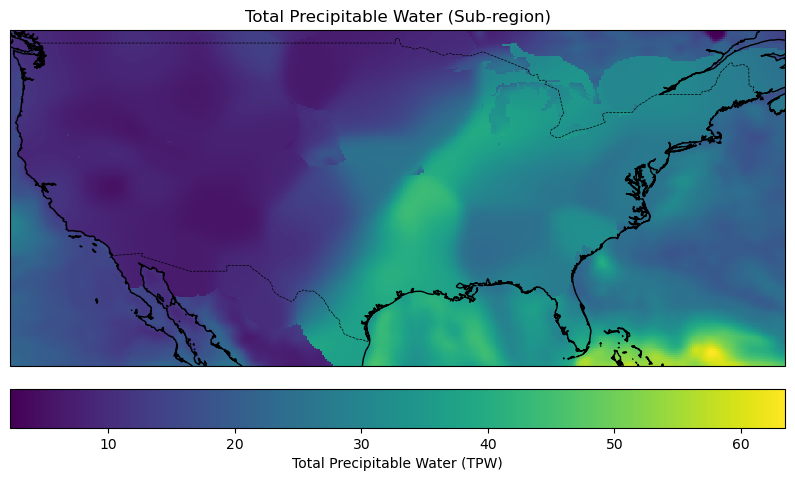

In [7]:


# Assuming lats, lons, and TPWs are already loaded
# Define the region of interest (example: a small area in lat/lon)
lat_min, lat_max = 24, 50  # Latitude bounds
lon_min, lon_max = -125, -65  # Longitude bounds

# Mask the TPWs data outside the region of interest
lat_mask = (lats >= lat_min) & (lats <= lat_max)
lon_mask = (lons >= lon_min) & (lons <= lon_max)

# Select the relevant sub-region
TPW_sub = TPWs[np.ix_(lat_mask, lon_mask)].data
lats_sub = lats[lat_mask].data
lons_sub = lons[lon_mask].data

# Create a meshgrid for the sub-region
lon_grid, lat_grid = np.meshgrid(lons_sub, lats_sub)

# Set up the plot for the sub-region
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10, 6))

# Add map features
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle='--')

# Set the extent to the region of interest
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

# # Plot the sub-region TPW data
tpw_plot = ax.pcolormesh(lon_grid, lat_grid, TPW_sub, transform=ccrs.PlateCarree(), cmap='viridis')

# # Add a colorbar
cbar = plt.colorbar(tpw_plot, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_label('Total Precipitable Water (TPW)')

# # Add title and labels
ax.set_title('Total Precipitable Water (Sub-region)')
plt.show()



## Map of the whole world

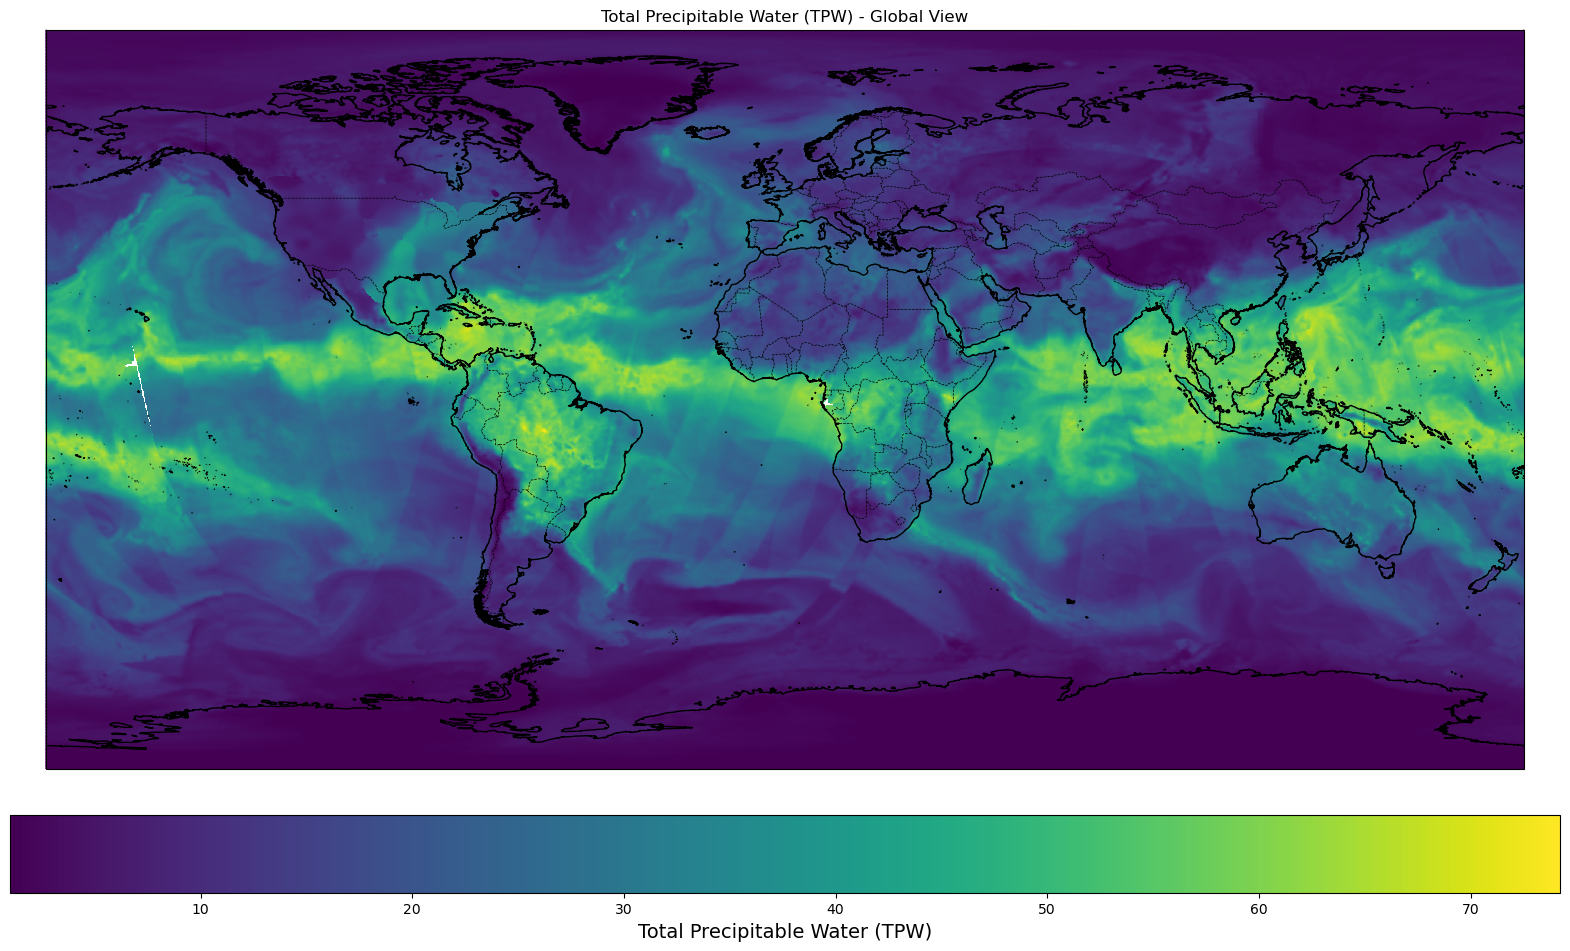

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Assuming lats, lons, and TPWs are already loaded

# Create a meshgrid for the full region (no restriction)
lon_grid, lat_grid = np.meshgrid(lons, lats)

# Set up the plot for the full region (whole world)
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(20, 12))

# Add map features
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle='--')

# Set the extent to cover the whole world (global view)
ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())

# Plot the entire TPW data globally
tpw_plot = ax.pcolormesh(lon_grid, lat_grid, TPWs, transform=ccrs.PlateCarree(), cmap='viridis')

# Add a colorbar
cbar = plt.colorbar(tpw_plot, ax=ax, orientation='horizontal', pad=0.05)
cbar.set_label('Total Precipitable Water (TPW)',fontsize=14)

# Add title and labels
ax.set_title('Total Precipitable Water (TPW) - Global View')
plt.show()


## Map by satellite number

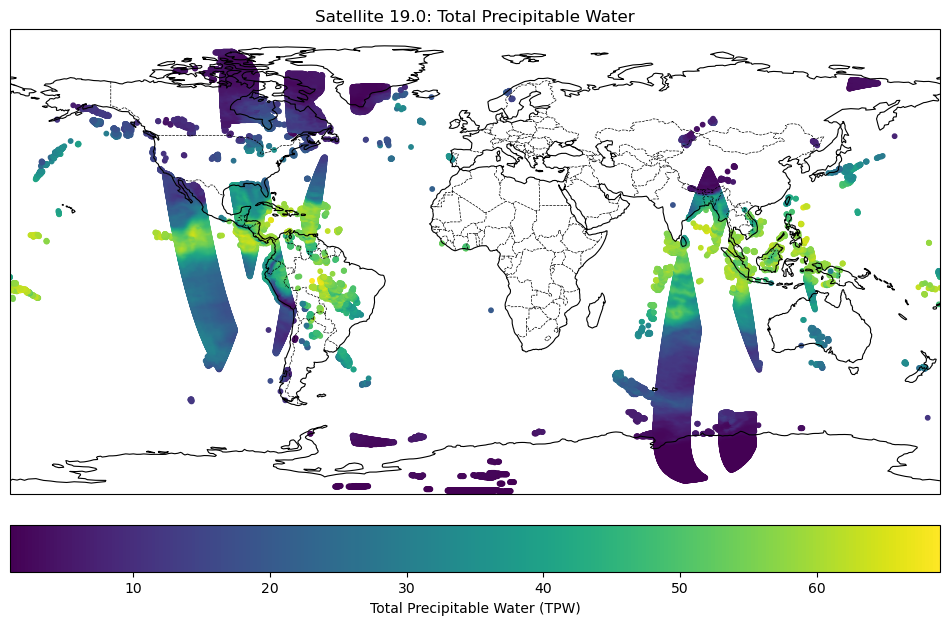

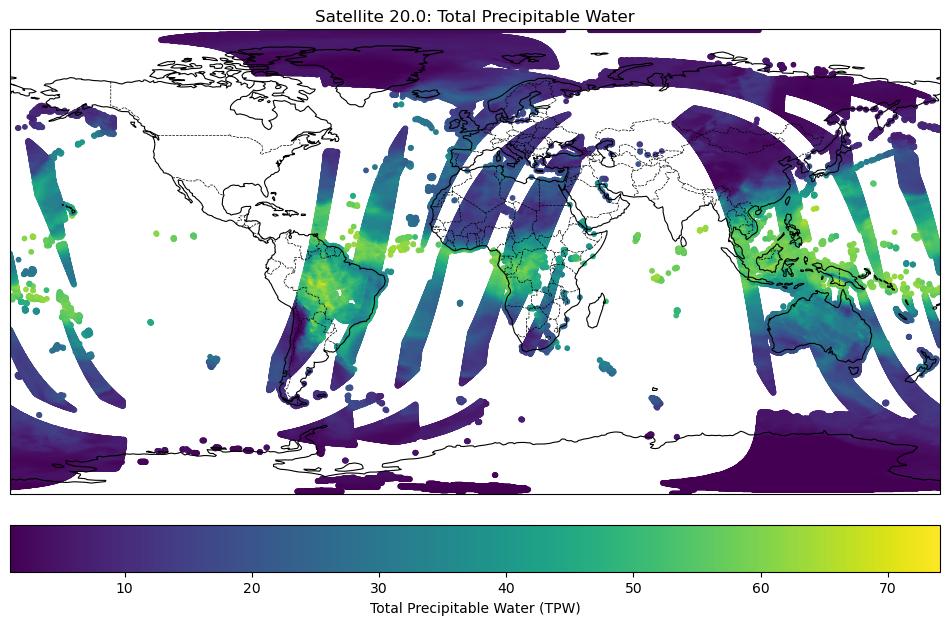

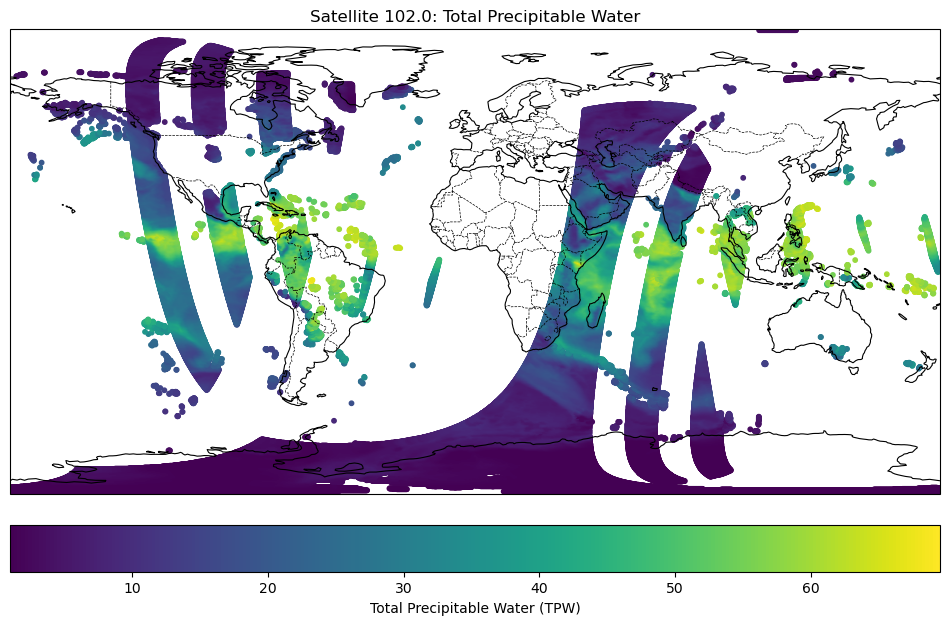

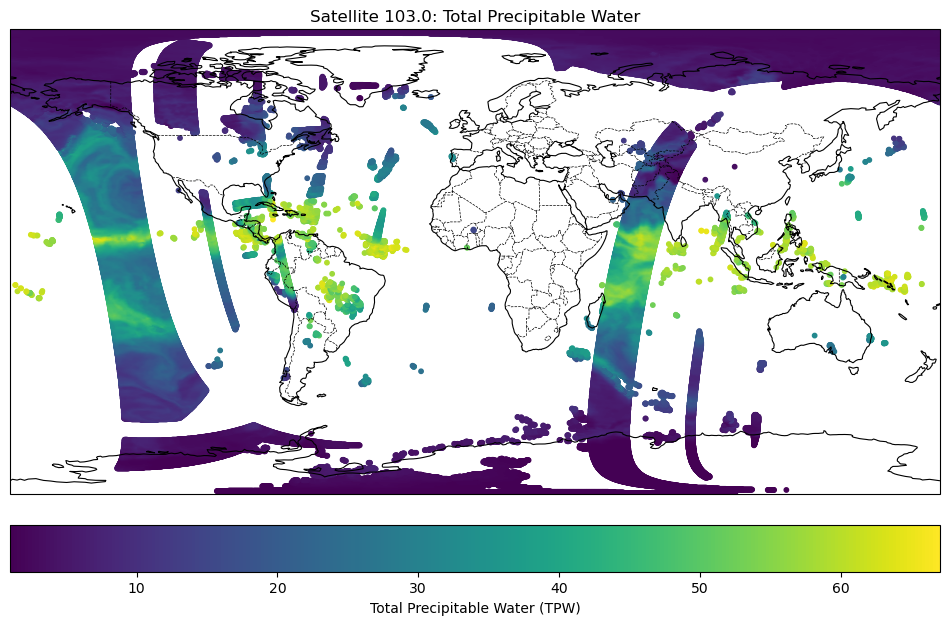

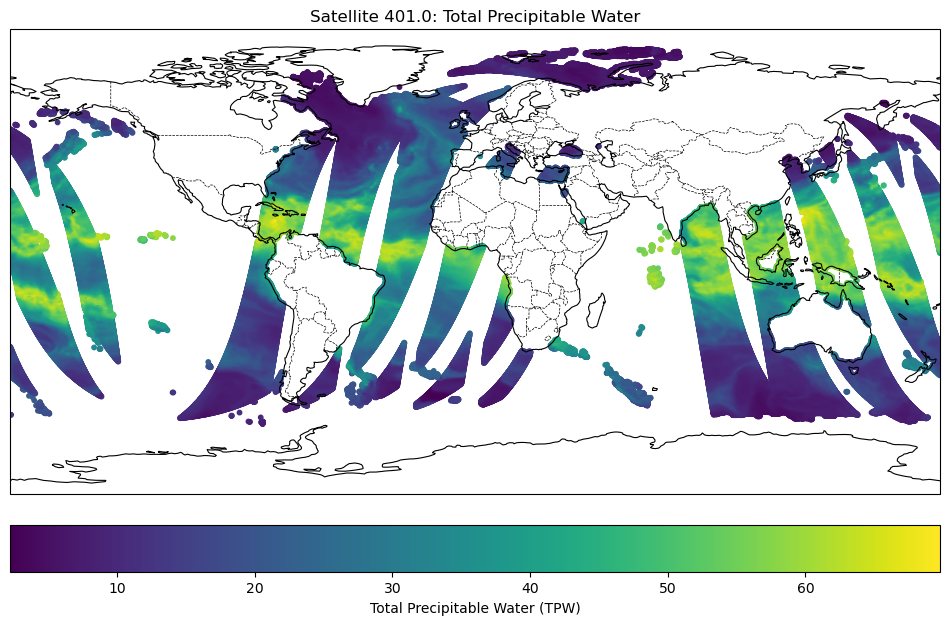

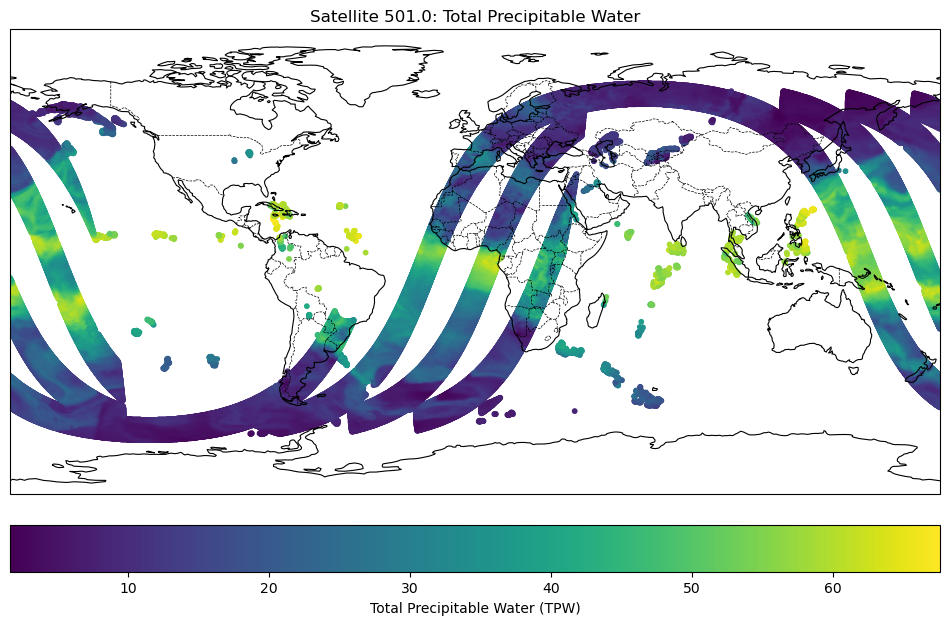

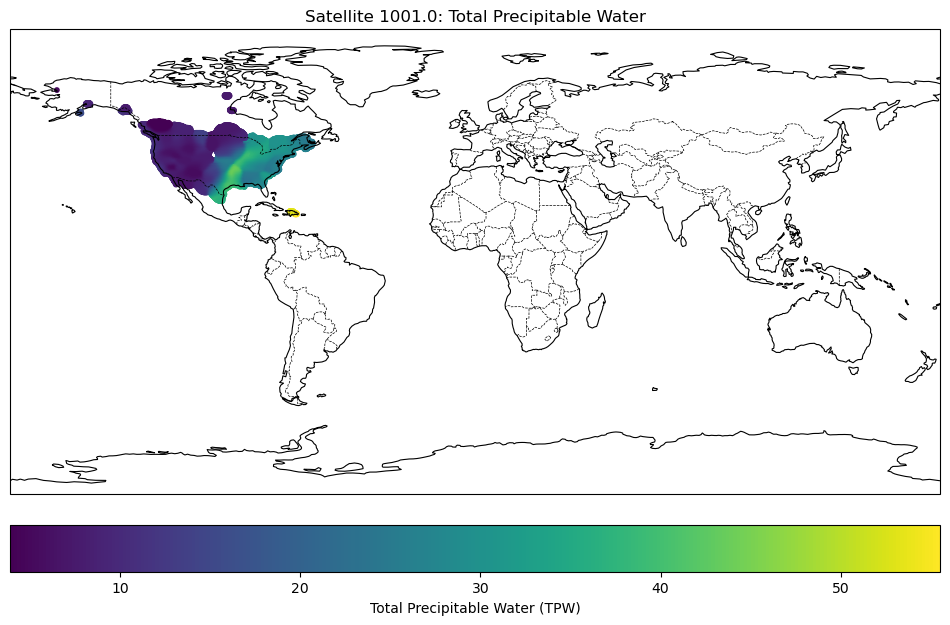

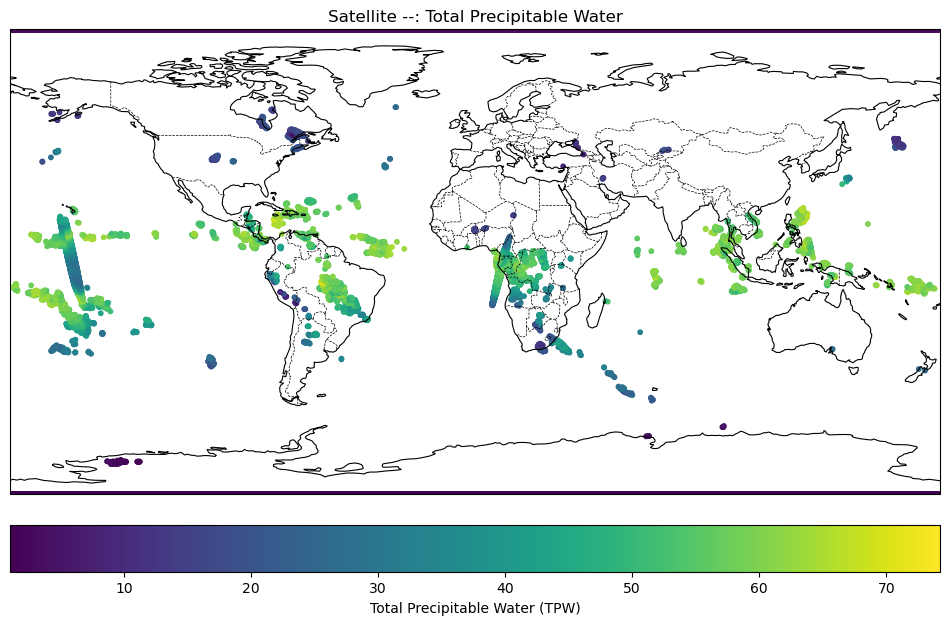

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Example data loading
# lats, lons, TPWs, observation_ages, satellite_numbers are assumed to be loaded

# Get unique satellite numbers
lon_grid, lat_grid = np.meshgrid(lons.data, lats.data)
#TPWs=TPWs.data

# valid_mask = satellite_numbers != -999
# lat_grid= lat_grid[valid_mask]
# lon_grid = lon_grid[valid_mask]
# TPWs = TPWs[valid_mask]
# satellite_numbers = satellite_numbers[valid_mask]
unique_satellites = np.unique(satellite_numbers)

# Create a figure for each satellite
for sat in unique_satellites:
    
    # Mask data for the current satellite
    mask = satellite_numbers == sat
    lats_sat = lat_grid[mask]
    lons_sat = lon_grid[mask]
    TPWs_sat = TPWs[mask]

    # Set up the map
    fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(12, 8))
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle='--', linewidth=0.5)
    ax.set_global()  # Display the whole globe

    # Plot TPWs for the satellite
    scatter = ax.scatter(
        lons_sat, lats_sat, c=TPWs_sat, cmap='viridis', s=10,
        transform=ccrs.PlateCarree()
    )

    # Add a colorbar
    cbar = plt.colorbar(scatter, ax=ax, orientation='horizontal', pad=0.05)
    cbar.set_label('Total Precipitable Water (TPW)')

    # Add title
    ax.set_title(f'Satellite {sat}: Total Precipitable Water')
    plt.show()


## Map by satellite number in USA

Satellite Number 19.0: 8093 observations
Satellite Number 102.0: 7199 observations
Satellite Number 103.0: 1257 observations
Satellite Number 401.0: 8964 observations
Satellite Number 501.0: 28 observations
Satellite Number 1001.0: 44006 observations
Satellite Number --: 345 observations


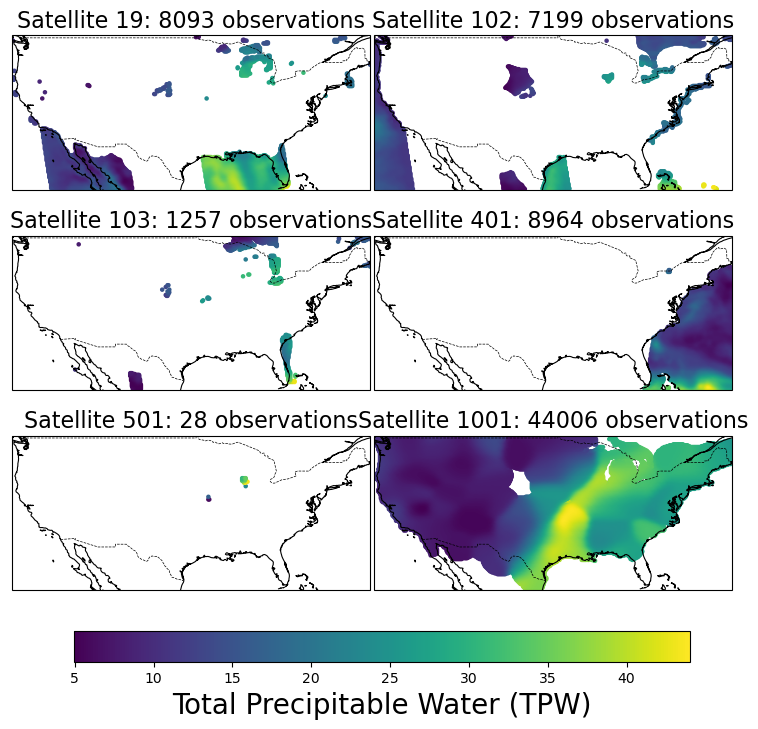

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import os





path = "real_data/First_scenario/data/Blended-Hydro_TPW_MAP_d20241105/"
files = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]
file_path=path+files[0]
file2read = Dataset(file_path)


lats=file2read.variables['lat'][:]
lons=file2read.variables['lon'][:]
TPWs=file2read.variables['TPW'][:]
observation_ages=file2read.variables['observation_age'][:]
satellite_numbers=file2read.variables['Satellite_Number'][:]
quality_informations=file2read.variables['quality_information'][:]
quality_flags=file2read.variables['quality_flag'][:]
lon_grid, lat_grid = np.meshgrid(lons.data, lats.data)


lat_min, lat_max = 15, 75  # Latitude range for North America
lon_min, lon_max = -170, -50  # Longitude range for North America


lat_min, lat_max = 24.396308, 49.384358
lon_min, lon_max = -125.0,-66.93457


region_mask = (
        (lat_grid >= lat_min) & (lat_grid <= lat_max) &
        (lon_grid >= lon_min) & (lon_grid <= lon_max)
    )
lats_region = lat_grid[region_mask]
lons_region = lon_grid[region_mask]
TPWs_region = TPWs[region_mask]
satellite_numbers_region=satellite_numbers[region_mask]

# Get unique satellite numbers
unique_satellites, counts = np.unique(satellite_numbers_region, return_counts=True)

# Display results
for satellite, count in zip(unique_satellites, counts):
    print(f"Satellite Number {satellite}: {count} observations")
unique_satellites=unique_satellites.compressed()

# Create a figure for each satellite
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

fig, axs = plt.subplots(
    nrows=3, ncols=2,  # Adjust rows/cols based on the number of satellites
    subplot_kw={'projection': ccrs.PlateCarree()},
    figsize=(8, 8),
    gridspec_kw={'hspace': 0.001, 'wspace': 0.01}  # Reduced hspace for smaller vertical spacing
)

# Flatten the axs array for easier indexing
axs = axs.flatten()

for idx, sat in enumerate(unique_satellites):
    if idx >= len(axs):  # Skip extra satellites if more than subplot slots
        break

    # Mask data for the current satellite
    mask = satellite_numbers_region == sat
    lats_sat = lats_region[mask]
    lons_sat = lons_region[mask]
    TPWs_sat = TPWs_region[mask]
    valid_indices = ~TPWs_sat.mask

    # Further filter data
    lats_sat = lats_sat[valid_indices]
    lons_sat = lons_sat[valid_indices]
    TPWs_sat = TPWs_sat[valid_indices]

    # Current subplot
    ax = axs[idx]

    # Add map features
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle='--', linewidth=0.5)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    #Plot TPWs for the satellite with smaller points
    scatter = ax.scatter(
        lons_sat, lats_sat, c=TPWs_sat, cmap='viridis', s=5,  # Smaller point size
        transform=ccrs.PlateCarree()
    )

    # Add title
    ax.set_title(f'Satellite {int(sat)}: {counts[idx]} observations', fontsize=16)

# Add a global colorbar for all subplots
cbar=fig.colorbar(scatter, ax=axs, orientation='horizontal', pad=0.1, fraction=0.05)
cbar.set_label('Total Precipitable Water (TPW)', fontsize=20)  # Correct way to set fontsize

# Fine-tune layout to make panels closer
plt.subplots_adjust(top=0.95, bottom=0.2, left=0.05, right=0.95, hspace=0.008,wspace=0.008)

# Save and show
plt.savefig("real_data/First_scenario/estimation/partition.pdf")
plt.show()




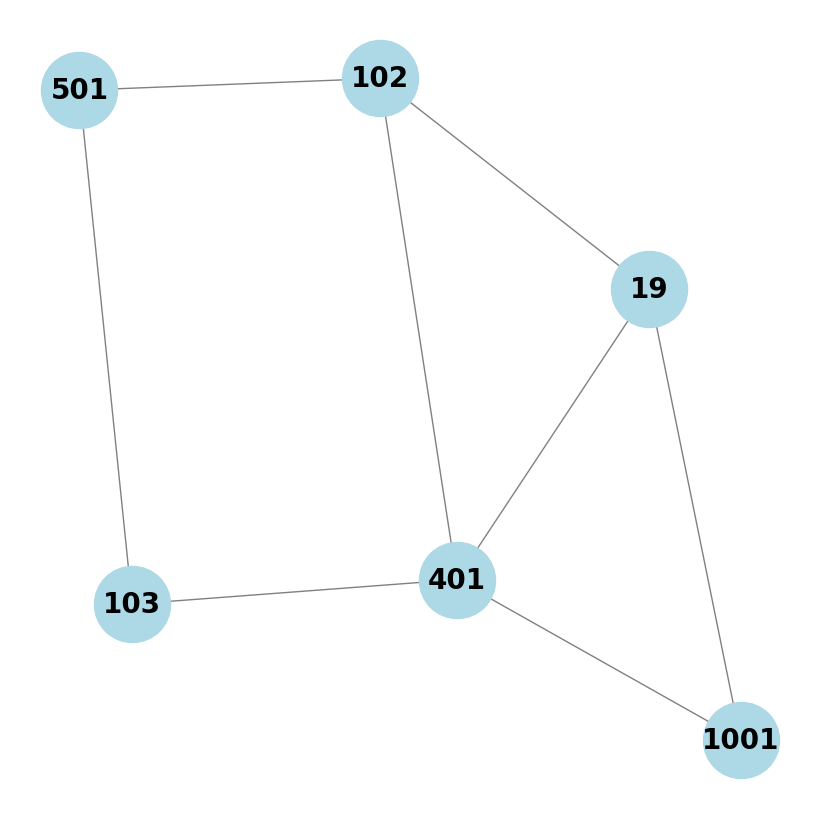

In [11]:


import unittest
import torch
from scipy.optimize import minimize
from src.estimation_torch import GPPEstimation  # Assuming your class is defined in gppestimation.py
from src.generation import GPPSampleGenerator
from sklearn.gaussian_process.kernels import Matern
import math
from src.kernel import exponential_kernel,onedif_kernel,matern_kernel_factory,matern_kernel
from src.networks import generate_connected_erdos_renyi_graph
from src.weights import optimal_weight_matrix
import networkx as nx
import numpy as np
import random
import pickle
from functools import partial
import multiprocessing
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

J=6
con_pro=0.5
er = generate_connected_erdos_renyi_graph(J, con_pro)
adj_matrix=nx.adjacency_matrix(er).todense()
np.fill_diagonal(adj_matrix, 1)
weights,_=optimal_weight_matrix(adj_matrix=adj_matrix)
weights=torch.tensor(weights,dtype=torch.double)


# Remove self-loops by setting diagonal to 0
np.fill_diagonal(adj_matrix, 0)

# Create a graph from the adjacency matrix
G = nx.from_numpy_array(adj_matrix)

# Define custom labels for the nodes
labels = {0: "Node A", 1: "Node B", 2: "Node C", 3: "Node D"}
labels={i:f"{int(unique_satellites[i])}" for i in range(6)}
# Draw the graph with custom labels
plt.figure(figsize=(8, 8))
pos = nx.spring_layout(G)  # Spring layout for a nice arrangement
nx.draw(
    G, pos, with_labels=True, labels=labels, node_color='lightblue',
    node_size=3000, edge_color='gray', font_weight='bold',font_size=20
)
#plt.title("Graph Representation without Self-Loops")
plt.savefig("real_data/First_scenario/estimation/connection_network.pdf")
plt.show()


In [13]:
import pickle
import pickle

# Path to your pickle file
file_path = "real_data/First_scenario/estimation/output/local_estimators.pkl"

# Read data from the pickle file
with open(file_path, "rb") as file:
    local_estimators = pickle.load(file)

In [14]:
local_estimators[2]

[None, None, None, None, None, None]

In [15]:
local_estimators[3]

[tensor(0.2975, dtype=torch.float64),
 tensor(1.3280, dtype=torch.float64),
 tensor(0.8182, dtype=torch.float64),
 tensor(0.2688, dtype=torch.float64),
 tensor(1.4111, dtype=torch.float64),
 tensor(0.6445, dtype=torch.float64)]

In [16]:
local_estimators[4]

[tensor([[4.1591e+03],
         [1.5865e-01]], dtype=torch.float64),
 tensor([[1.1928e+04],
         [9.0301e-02]], dtype=torch.float64),
 tensor([[1.9867e+04],
         [1.6506e-01]], dtype=torch.float64),
 tensor([[2.1596e+03],
         [1.1064e-01]], dtype=torch.float64),
 tensor([[4.6040e+03],
         [6.5489e-02]], dtype=torch.float64),
 tensor([[2.6997e+03],
         [4.0412e-01]], dtype=torch.float64)]

In [18]:

# what is the next step
# 1. determine the area to be analyzed: done (north american)
# 2. Partition the data into two parts: done
# 3. One part is for parameter estimation, then predict the value in the other part
# # 3.1 Which distance function should I use: just use the chordal distance induced by the Euclidean distance (refer literature)
# # 3.2 incorporate the intercept: yes
# 4. compare the decentralized method with MLE

# 5. compare with the method in the paper in terms of computational efficiency, estimation accuracy and prediction accuracy?
import warnings

# Suppress FutureWarning from torch.load
#warnings.filterwarnings("ignore")

warnings.simplefilter("error", FutureWarning)

import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np



import unittest
import torch
from scipy.optimize import minimize
from src.estimation_torch_real_data import GPPEstimation  # Assuming your class is defined in gppestimation.py
from src.generation import GPPSampleGenerator
from sklearn.gaussian_process.kernels import Matern
import math
from src.kernel import exponential_kernel,onedif_kernel,matern_kernel_factory,matern_kernel
from src.networks import generate_connected_erdos_renyi_graph
from src.weights import optimal_weight_matrix
import networkx as nx
import numpy as np
import random
import pickle
from functools import partial
import multiprocessing
import matplotlib.pyplot as plt
from joblib import Parallel, delayed


file_path = "real_data/First_scenario/estimation/output/optimal_estimator.pkl"

with open(file_path, "rb") as file:
        optimal_estimator = pickle.load(file)


path = "real_data/First_scenario/data/Blended-Hydro_TPW_MAP_d20241105/"
files = [f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))]
file_path=path+files[0]
file2read = Dataset(file_path)


lats=file2read.variables['lat'][:]
lons=file2read.variables['lon'][:]
TPWs=file2read.variables['TPW'][:]
observation_ages=file2read.variables['observation_age'][:]
satellite_numbers=file2read.variables['Satellite_Number'][:]
quality_informations=file2read.variables['quality_information'][:]
quality_flags=file2read.variables['quality_flag'][:]
lon_grid, lat_grid = np.meshgrid(lons.data, lats.data)



#select the data 
lat_min, lat_max = 15, 75  # Latitude range for North America
lon_min, lon_max = -170, -50  # Longitude range for North America


lat_min, lat_max = 15, 75  # Latitude range for North America
lon_min, lon_max = -170, -50  # Longitude range for North America

lon_grid, lat_grid = np.meshgrid(lons.data, lats.data)

region_mask = (
        (lat_grid >= lat_min) & (lat_grid <= lat_max) &
        (lon_grid >= lon_min) & (lon_grid <= lon_max)
    )
lats_NorthAmerican = lat_grid[region_mask]
lons_NorthAmerican = lon_grid[region_mask]
TPWs_NorthAmerican = TPWs[region_mask]
satellite_numbers_NorthAmerican =satellite_numbers[region_mask]

unique_satellites, counts = np.unique(satellite_numbers_NorthAmerican, return_counts=True)

# Display results
for satellite, count in zip(unique_satellites, counts):
    print(f"Satellite Number {satellite}: {count} observations")
unique_satellites=unique_satellites.compressed()
dis_data=[]
#divide the data according to sat
for sat in unique_satellites:
    mask = satellite_numbers_NorthAmerican == sat
    if sat==103.0:
        continue
    lats_sat = lats_NorthAmerican[mask]
    lons_sat = lons_NorthAmerican[mask]
    TPWs_sat = TPWs_NorthAmerican[mask]
    valid_indices = ~TPWs_sat.mask
    # Filter the arrays
    lats_sat = lats_sat[valid_indices]
    lons_sat = lons_sat[valid_indices]
    TPWs_sat = TPWs_sat[valid_indices]
    X=np.ones((lats_sat.shape[0],1))
    local_data=np.hstack((lats_sat.reshape(-1,1),lons_sat.reshape(-1,1),TPWs_sat.reshape(-1,1),X))
    dis_data.append(local_data)
full_data=np.vstack(dis_data)

Satellite Number 19.0: 46631 observations
Satellite Number 20.0: 20458 observations
Satellite Number 102.0: 66366 observations
Satellite Number 103.0: 103620 observations
Satellite Number 401.0: 46286 observations
Satellite Number 501.0: 11756 observations
Satellite Number 1001.0: 50081 observations
Satellite Number --: 1330 observations


## Convergence plot

In [20]:
import pickle
file_path_save="real_data/First_scenario/estimation/output/result.pkl"
with open(file_path_save, "rb") as file:
    result=pickle.load(file)
de_estimators,optimal_estimator=result

In [21]:
import numpy as np
import torch
error=np.zeros((100,))
for t in range(100):
    error_delta=np.zeros((6,))
    error_theta=np.zeros((6,))
    for j in range(6):
        error_delta[j]=torch.abs((de_estimators[3][t][j]-optimal_estimator[3])/optimal_estimator[3])
        error_theta[j]=torch.linalg.norm((de_estimators[4][t][j]-optimal_estimator[4])/optimal_estimator[4])
    error[t]=np.max(error_delta)+np.max(error_theta)
    

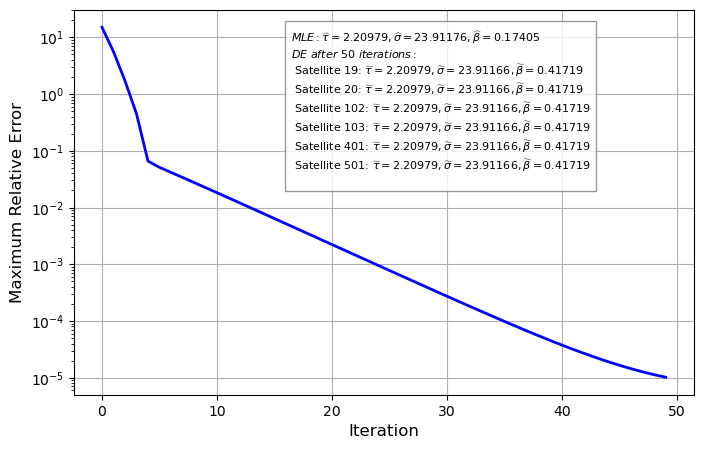

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import math
MLE_tau, MLE_sigma, MLE_beta = math.sqrt(1/optimal_estimator[3].item()), math.sqrt(optimal_estimator[4][0].item()), optimal_estimator[4][1].item()
DE_taus, DE_sigmas, DE_betas = np.zeros((6,)),np.zeros((6,)),np.zeros((6,))
for j in range(6):
    DE_taus[j]=math.sqrt(1/de_estimators[3][50][j].item())
    DE_sigmas[j]=math.sqrt(de_estimators[4][50][j][0].item())
    DE_betas[j]=math.sqrt(de_estimators[4][50][j][1].item())
# Example data
iterations = np.arange(0, 50)  # 100 iterations

# Create the line plot
plt.figure(figsize=(8, 5))
plt.plot(iterations, error[:50], label='Error', color='blue', linewidth=2)

# Customize the plot
plt.yscale('log')
#plt.title('Error Over Iterations', fontsize=14)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Maximum Relative Error', fontsize=12)
plt.grid(True)
#plt.legend(fontsize=10)
text_str = (
    r"$MLE: \widehat{{\tau}}={:.5f}, \widehat{{\sigma}}={:.5f}, \widehat{{\beta}}={:.5f}$" "\n"
    r"$DE\ after\ 50\ iterations:$" "\n"
).format(MLE_tau, MLE_sigma, MLE_beta)

# Add details for each satellite
for j in range(6):
    text_str += (
        f" Satellite {int(unique_satellites[j])}: " 
        r"$\widetilde{{\tau}}={:.5f}, \widetilde{{\sigma}}={:.5f}, \widetilde{{\beta}}={:.5f}$" "\n"
    ).format(DE_taus[j], DE_sigmas[j], DE_betas[j])

# Position the text in the top-right corner
plt.text(
    0.35, 0.95, text_str,
    transform=plt.gca().transAxes, fontsize=8, va='top', ha='left',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'),
    multialignment='left',  # Ensure left-aligned text,
)

plt.savefig("real_data/First_scenario/estimation/output/convergence_plot.pdf")

plt.show()


In [ ]:
np.log10(error)

array([ 1.84656113,  1.53638304,  1.22587143,  0.86877379,  0.05028316,
       -0.38454587, -0.56596605, -0.66141135, -0.76435077, -0.86417058,
       -0.96149131, -1.05684642, -1.15064236, -1.24318764, -1.33473712,
       -1.42548981, -1.51558087, -1.60515955, -1.69432467, -1.78316194,
       -1.871769  , -1.9601899 , -2.04846565, -2.13663747, -2.22474664,
       -2.31283618, -2.40086109, -2.48895596, -2.57718101, -2.66554136,
       -2.75407322, -2.84283228, -2.9314456 , -3.02053038, -3.11043585,
       -3.20055001, -3.2914518 , -3.38366151, -3.47694863, -3.56876346,
       -3.66309604, -3.76195051, -3.86195139, -3.96633573, -4.0773843 ,
       -4.19546494, -4.31822087, -4.44098248, -4.58007834, -4.76438693,
       -5.00090244, -5.39126681, -5.43770464, -5.02410548, -4.85987151,
       -4.76787143, -4.70506782, -4.65941151, -4.62541387, -4.59935319,
       -4.57965043, -4.56299465, -4.55054314, -4.54063533, -4.53255142,
       -4.52603515, -4.52073904, -4.51637141, -4.51295439, -4.51